# Baseline colorization model with autoencoder-like architecture

## Imports

In [1]:
#Algebra
import numpy as np

#Graphics
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

#Deep learning
import tensorflow as tf
import tensorflow_io as tfio

from keras.models import Model
from keras import optimizers, callbacks
from keras.layers import  Input, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten, Dense, Reshape
from keras.utils import image_dataset_from_directory

#Saving models
import joblib

2026-05-05 15:42:58.694307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777995778.920564      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777995778.986997      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777995779.521588      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777995779.521643      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777995779.521646      57 computation_placer.cc:177] computation placer alr

## Training dataset

In [2]:
train_data_dir = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color'

## Parameters

In [3]:
BATCH_SIZE = 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
NUM_CHANNELS = 3

SEED = 42

LEARNING_RATE = 0.01
PATIENCE = 20
EPOCHS = 5

In [4]:
train_ds, val_ds = image_dataset_from_directory(
    train_data_dir,
    labels=None,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 5000 files.
Using 4000 files for training.
Using 1000 files for validation.


I0000 00:00:1777995815.872015      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777995815.878052      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Converting RGB to Lab

In [5]:
def rgb_to_lab(image):
    image = tf.cast(image, tf.float32) / 255.0
    lab = tfio.experimental.color.rgb_to_lab(image)
    L = lab[:, :, :, :1] / 100.
    ab = lab[:, :, :, 1:] / 128.
    return (L, ab)

In [6]:
train_ds_lab = train_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_lab = train_ds_lab.prefetch(tf.data.AUTOTUNE)
val_ds_lab = val_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_lab = val_ds_lab.prefetch(tf.data.AUTOTUNE)

## Defining the model

In [7]:
def initialize_model():

    ######################
    ###  Architecture  ###
    ######################

    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))  #B&W images (L channel)

    #Encoder part
    x = Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    #Decoder part
    x = Conv2DTranspose(64, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)

    x = Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='same')(x)

    outputs = Conv2DTranspose(2, kernel_size=(3, 3), strides=(2, 2), activation='tanh', padding='same')(x)  #ab channels

    
    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='mse',
              optimizer=adam,
              metrics=['mse'])

    return model

In [8]:
baseline = initialize_model()
baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 256, 256, 2)    │           578 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,506 (724.63 KB)

 Trainable params: 185,506 (724.63 KB)

 Non-trainable params: 0 (0.00 B)

### Callbacks

In [9]:
LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

### Training

In [10]:
%%time
history = baseline.fit(train_ds_lab,
                    epochs=EPOCHS,
                    validation_data=val_ds_lab,
                    callbacks=[EarlyStopper],
                    verbose=1)

Epoch 1/5


I0000 00:00:1777995821.932450     136 service.cc:152] XLA service 0x795bc408f620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777995821.932491     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777995821.932496     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777995822.594897     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-05 15:43:45.442035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 15:43:45.607448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 15:43:46.452709: E external/local_xl

  1/125 ━━━━━━━━━━━━━━━━━━━━ 26:52 13s/step - loss: 0.0164 - mse: 0.0164

I0000 00:00:1777995831.812613     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 0.0133 - mse: 0.0133

2026-05-05 15:44:33.746306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 15:44:33.901757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 343ms/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0125 - val_mse: 0.0125
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 310ms/step - loss: 0.0131 - mse: 0.0131 - val_loss: 0.0125 - val_mse: 0.0125
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 308ms/step - loss: 0.0132 - mse: 0.0132 - val_loss: 0.0127 - val_mse: 0.0127
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 310ms/step - loss: 0.0131 - mse: 0.0131 - val_loss: 0.0126 - val_mse: 0.0126
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 302ms/step - loss: 0.0131 - mse: 0.0131 - val_loss: 0.0127 - val_mse: 0.0127
CPU times: user 12min 4s, sys: 32.8 s, total: 12min 37s
Wall time: 3min 32s


In [13]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('MSE')
    ax[1].plot(history.epoch, history.history["mse"], label="Train MSE")
    ax[1].plot(history.epoch, history.history["val_mse"], label="Validation MSE")
    ax[0].legend()
    ax[1].legend()

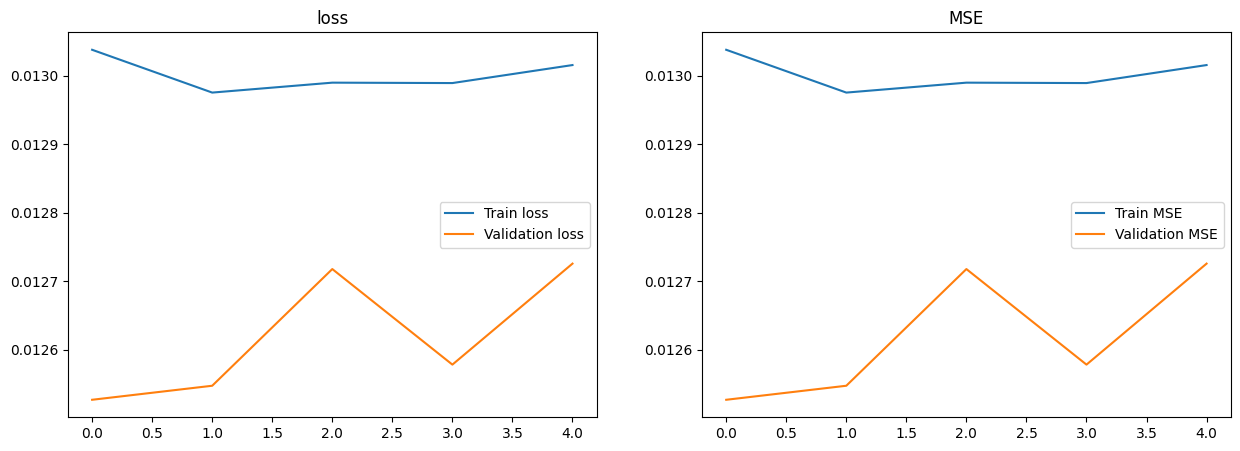

In [14]:
plot_history(history)

### Saving model

In [15]:
joblib.dump(baseline, "/kaggle/working/baseline.joblib")

['/kaggle/working/baseline.joblib']

## Testing reconstruction on image from train set

In [16]:
image_color_path = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color/image0001.jpg'

In [17]:
img = np.array(Image.open(image_color_path).resize((256,256)))
img.shape
L, ab = rgb_to_lab(np.expand_dims(img, axis=0))

In [18]:
ab_pred = baseline.predict(L)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step


In [19]:
ab_pred.shape

(1, 256, 256, 2)

In [38]:
img_lab_reconstructed = tf.concat([L * 100.0, ab_pred * 128.0], axis=-1)

In [39]:
img_rgb_reconstructed = tfio.experimental.color.lab_to_rgb(img_lab_reconstructed)
img_rgb_reconstructed.shape

TensorShape([1, 256, 256, 3])

In [40]:
img_bw_path = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_black/image0001.jpg'

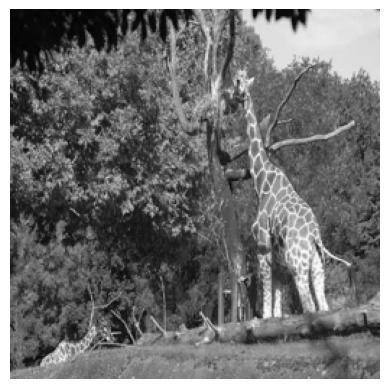

In [41]:
img_bw = np.array(Image.open(img_bw_path).resize((256,256)))
plt.imshow(img_bw)
plt.axis('off');

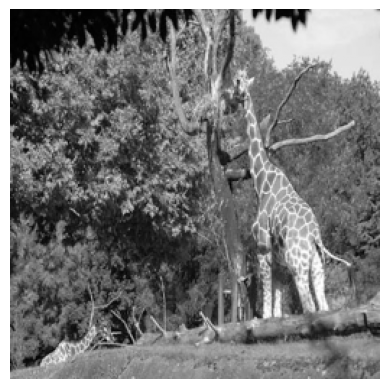

In [42]:
plt.imshow(np.squeeze(L, axis=0), cmap='grey')
plt.axis('off');

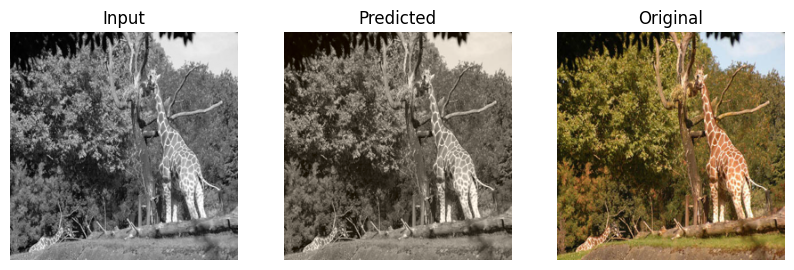

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))

ax[0].imshow(np.squeeze(L, axis=0), cmap='grey')
ax[0].axis('off')
ax[0].set_title('Input')

ax[1].imshow(np.squeeze(img_rgb_reconstructed,axis=0))
ax[1].axis('off')
ax[1].set_title('Predicted')

ax[2].imshow(img)
ax[2].axis('off')
ax[2].set_title('Original');